<a href="https://colab.research.google.com/github/miriam-silva/amt4-s1a2026/blob/main/MultiNeuralCensus1905.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes| Digest GaussianNB [Fase 1 - census]

## Importar dados do Drive

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Bibliotecas de Python

In [7]:
!pip -q install plotly
!pip -q install yellowbrick

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census


In [9]:
import pickle

In [10]:
with open('/content/drive/MyDrive/AprendizagemDeMaquinaIcoma/am-t4/census.pkl', 'rb') as f:
 X_census_trainamento,Y_census_trainamento,X_census_teste,Y_census_teste = pickle.load(f)

In [11]:
X_census_trainamento.shape ,Y_census_trainamento.shape

((27676, 108), (27676,))

In [12]:
X_census_teste.shape ,Y_census_teste.shape

((4885, 108), (4885,))

In [13]:
from sklearn.naive_bayes import GaussianNB

In [14]:
naive_census_data = GaussianNB()
naive_census_data.fit(X_census_trainamento,Y_census_trainamento)

GaussianNB()

## Criando base Previsora


In [15]:
census_predict = naive_census_data.predict(X_census_teste)

In [16]:
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [17]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [20]:
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [21]:
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

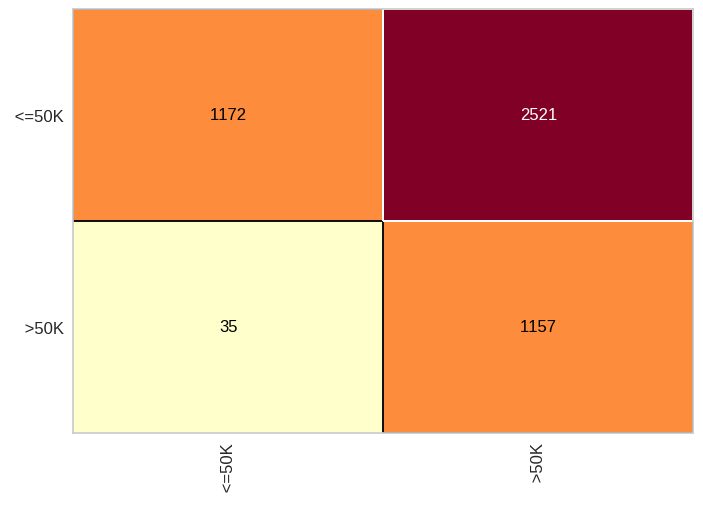

In [23]:
cm_census = ConfusionMatrix(naive_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)


# Pipeline Árvore de Decisão | Treemap Base [Fase 2 - census]

In [24]:
from sklearn.tree import DecisionTreeClassifier

In [25]:
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)
arvore_census_data.fit(X_census_trainamento,Y_census_trainamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [26]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion="entropy",
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='better')

DecisionTreeClassifier(criterion='entropy', random_state=0, splitter='better')

In [27]:
previsao_arvore_census = arvore_census_data.predict(X_census_teste)

In [30]:
previsao_arvore_census

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [31]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

# Pipeline Medições Harmônicas | Treemap Base [Fase 3 - credit_data]

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:
accuracy_score(Y_census_teste, previsao_arvore_census)

0.8104401228249745

0.8104401228249745

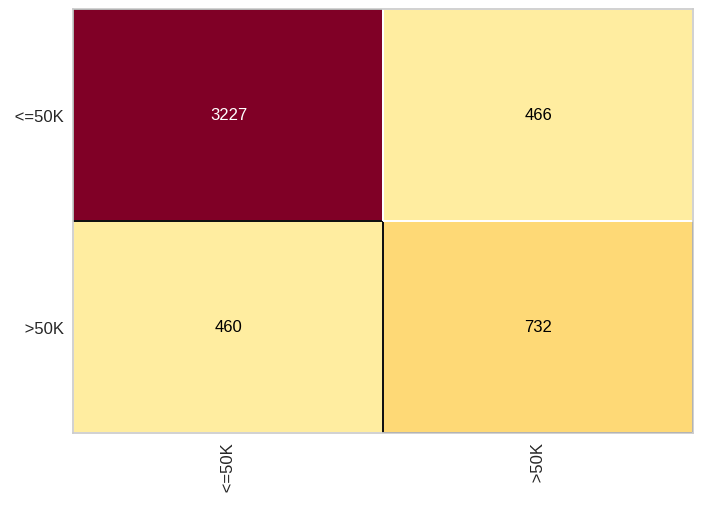

In [35]:
from yellowbrick.classifier import ConfusionMatrix
cm_census = ConfusionMatrix(arvore_census_data)
cm_census.fit(X_census_trainamento, Y_census_trainamento)
cm_census.score(X_census_teste, Y_census_teste)

In [36]:
print(classification_report(Y_census_teste, previsao_arvore_census))

              precision    recall  f1-score   support

       <=50K       0.88      0.87      0.87      3693
        >50K       0.61      0.61      0.61      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.74      0.74      4885
weighted avg       0.81      0.81      0.81      4885

